# Global Supply Chain Risk Analysis

This notebook presents a comprehensive analysis of global supply chain risks, utilizing the `global_supply_chain_risk_2026.csv` dataset. The project aims to identify key factors influencing supply chain disruptions and lead times, offering insights into optimizing supply chain resilience.

## Table of Contents:

1.  **Data Inspection and Cleaning**: Initial exploration, handling missing values and duplicates, and data type conversions.
2.  **Descriptive Statistics**: Summary statistics for key numerical features.
3.  **Transport Mode Analysis**: Examination of shipment distribution across different transport modes and their disruption rates.
4.  **Risk and Reliability Assessment**: Analysis of carrier reliability scores and geopolitical risks across various routes and weather conditions.
5.  **Predictive Analytics & Anomaly Detection**: Development of a linear regression model to predict lead times and identification of anomalous shipments.

In [80]:
# importig all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [81]:
# Reading the dataset and viewing the first and last five records

df = pd.read_csv('/content/global_supply_chain_risk_2026.csv')
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [82]:
df.tail()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1
4999,SC-14999,2024-06-01,Dubai,Shanghai,Air,Textiles,9161.03,109.35,2.03,1.7,Storm,0.976,1.43,1


# DATA INSPECTION AND CLEANING


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

In [84]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['Month_Number'] = df['Date'].dt.month

In [85]:
print("There are ", df['Origin_Port'].nunique(), "origin ports in general ",
      'and they are ', df['Origin_Port'].unique())

print()
print("There are ", df['Destination_Port'].nunique(), " destination ports in general ",
      'and they are ', df['Destination_Port'].unique())

print()
print('There are', df.isna().sum().sum(), 'missing values in the dataset. Here is the breakdown per column:')
print(df.isna().sum())




There are  8 origin ports in general  and they are  ['Singapore' 'Rotterdam' 'Busan' 'Shanghai' 'Dubai' 'Los Angeles'
 'Hamburg' 'Antwerp']

There are  9  destination ports in general  and they are  ['Los Angeles' 'Shanghai' 'Hamburg' 'Singapore' 'Marseille' 'Antwerp'
 'Rotterdam' 'Busan' 'Dubai']

There are 0 missing values in the dataset. Here is the breakdown per column:
Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
Month                        0
Month_Number                 0
dtype: int64


In [86]:
print(f"There are {df.duplicated().sum()} duplicates")



There are 0 duplicates


# DESCRIPTIVE STATISTICS

In [87]:
df[['Distance_km', 'Weight_MT']].describe()

,Distance_km,Weight_MT
count,5000.000000,5000.000000
mean,7704.063888,246.252052
std,4199.687885,142.522591
min,500.170000,1.030000
25%,4036.010000,124.330000
50%,7750.125000,243.500000
75%,11347.462500,366.955000
max,14995.910000,499.750000


In [88]:
description = df[['Distance_km', 'Weight_MT']].describe()
print("Below are the mean, median and standard deviation value\nfor distance covered in Km and Weight of goods in MT")
print(description.loc[['mean', 'std', '50%']])

# des = df[['Distance_km', 'Weight_MT']].agg(('mean', 'median', 'std'))
# print(des)

Below are the mean, median and standard deviation value
for distance covered in Km and Weight of goods in MT
      Distance_km   Weight_MT
mean  7704.063888  246.252052
std   4199.687885  142.522591
50%   7750.125000  243.500000


# TRANSPORT MODE ANALYSIS

In [89]:
# CHECKING FOR THE FREQUENCY OF TRANSPORT MODE
df['Transport_Mode'].value_counts()

,count
Transport_Mode,
Air,1320
Sea,1281
Road,1214
Rail,1185


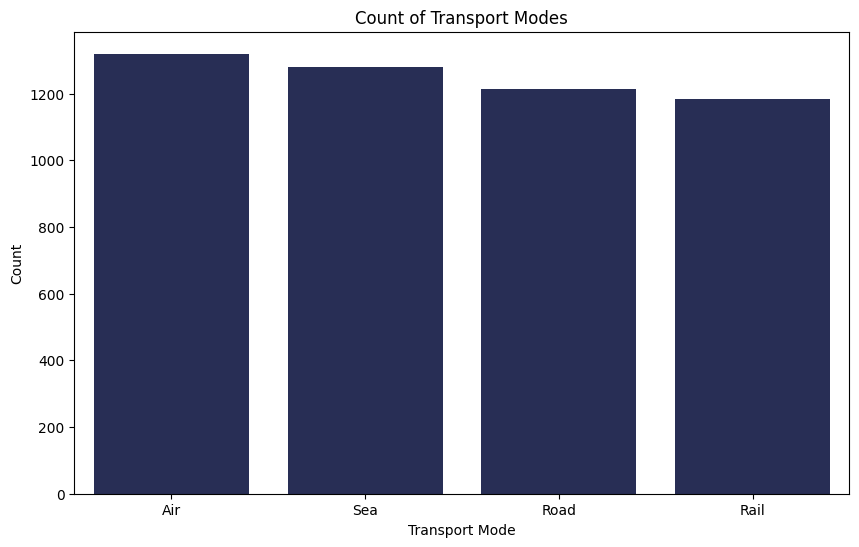

In [90]:
plt.figure(figsize=(10, 6))
sns.countplot(x= 'Transport_Mode', data= df, order = df['Transport_Mode'].value_counts().index, color="#21295C")

plt.xlabel('Transport Mode')
plt.ylabel('Count')
plt.title('Count of Transport Modes')
plt.savefig('transport_mode_count.png')
plt.show()

### Analysis of shipment affected by "Hurricane"

In [91]:

hurricane  = df['Weather_Condition']== 'Hurricane'
hur = hurricane.sum()
print(f'Out of {df['Shipment_ID'].count()}, about {hur} shipment Experienced Hurricane ')
print("Below are the subset of the  data")
df[(df['Weather_Condition']== 'Hurricane') & (df['Disruption_Occurred']== 1)]

Out of 5000, about 990 shipment Experienced Hurricane 
Below are the subset of the  data


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Month,Month_Number
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,October,10
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,October,10
15,SC-10015,2024-04-05,Antwerp,Marseille,Rail,Perishables,3159.37,106.66,1.25,8.5,Hurricane,0.950,25.50,1,April,4
23,SC-10023,2025-10-27,Busan,Shanghai,Air,Perishables,5812.25,359.90,1.23,7.7,Hurricane,0.836,3.30,1,October,10
25,SC-10025,2025-07-12,Shanghai,Singapore,Air,Electronics,11885.05,264.27,1.70,8.8,Hurricane,0.693,6.86,1,July,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4980,SC-14980,2025-08-01,Rotterdam,Singapore,Air,Electronics,14670.62,177.60,2.06,8.9,Hurricane,0.787,8.49,1,August,8
4984,SC-14984,2025-06-15,Antwerp,Hamburg,Road,Textiles,8484.58,435.33,3.71,3.4,Hurricane,0.667,46.95,1,June,6
4986,SC-14986,2025-12-05,Hamburg,Dubai,Road,Perishables,11057.69,163.07,3.82,4.3,Hurricane,0.864,63.77,1,December,12
4990,SC-14990,2025-03-19,Hamburg,Busan,Sea,Electronics,14643.45,225.74,4.30,5.7,Hurricane,0.768,209.65,1,March,3


In [92]:
hurricane = df['Weather_Condition']== 'Hurricane'
print(f' There are {hurricane.sum()} that experienced hurricane')

 There are 990 that experienced hurricane


# DATA MANIPULATION AND ADVANCED VISUALIZATION

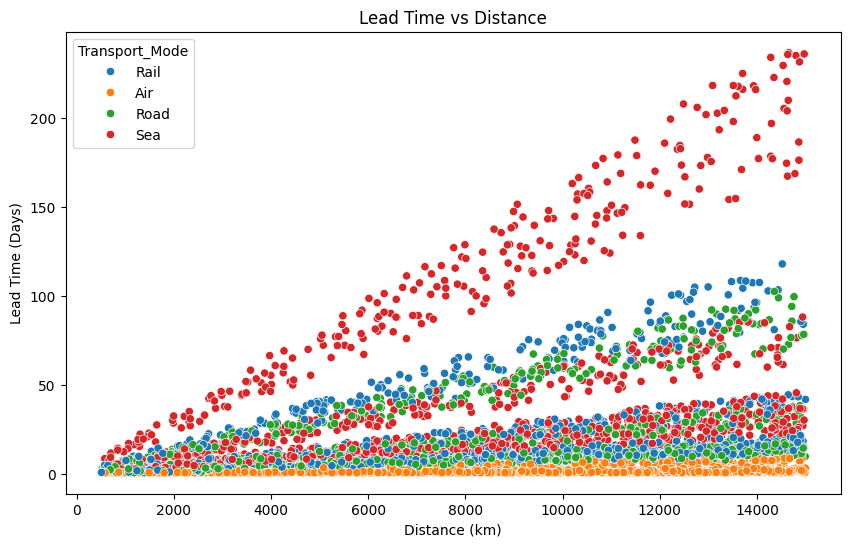

In [93]:
# relationship between leadtime and distance
plt.figure(figsize=(10, 6))
sns.scatterplot( x= 'Distance_km', y= 'Lead_Time_Days', hue = 'Transport_Mode',
                data = df, )
plt.xlabel
plt.ylabel('Lead Time (Days)')
plt.xlabel('Distance (km)')
plt.title('Lead Time vs Distance')
plt.savefig('lead_time_vs_distance.png')
plt.show()

In [94]:
# distruption rate by transport mode
dist = df[df['Disruption_Occurred'] == 1]
dist1 = dist.groupby('Transport_Mode')['Disruption_Occurred'].count()
total = dist['Shipment_ID'].count()
percentofdist = (dist1/total)*100
percentofdist


,Disruption_Occurred
Transport_Mode,
Air,26.607901
Rail,23.669605
Road,24.191969
Sea,25.530526


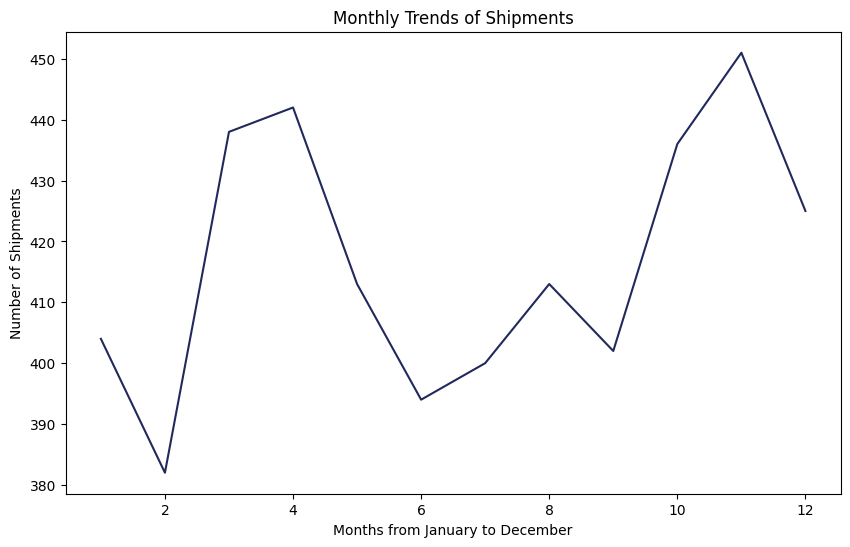

In [95]:
# monthly trends of shipments
mon = df['Month_Number'].value_counts().reset_index()
plt.figure(figsize= (10,6))

sns.lineplot(x = "Month_Number", y = 'count',  data= mon, estimator= np.count_nonzero , color="#21295C")

plt.title("Monthly Trends of Shipments")
plt.ylabel("Number of Shipments")
plt.xlabel("Months from January to December")
plt.show()

In [96]:
# credibility score for each weather impact
df.groupby('Weather_Condition')['Carrier_Reliability_Score'].mean()

,Carrier_Reliability_Score
Weather_Condition,
Clear,0.760835
Fog,0.754161
Hurricane,0.749155
Rain,0.752979
Storm,0.754761


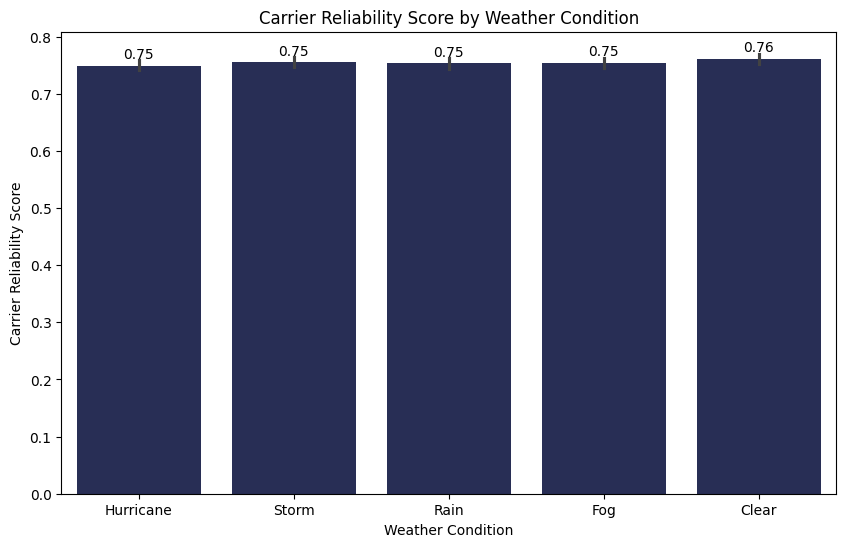

In [97]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(x= 'Weather_Condition', y= 'Carrier_Reliability_Score', data= df, estimator= "mean", color="#21295C")

for container in ax.containers:
  ax.bar_label(container, fmt='%.2f', padding=3)

plt.xlabel('Weather Condition')
plt.ylabel('Carrier Reliability Score')
plt.title('Carrier Reliability Score by Weather Condition')

plt.show()

/tmp/ipykernel_780/3450153437.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y= 'Route', x= 'Geopolitical_Risk_Score', data= top_5 , palette='viridis')


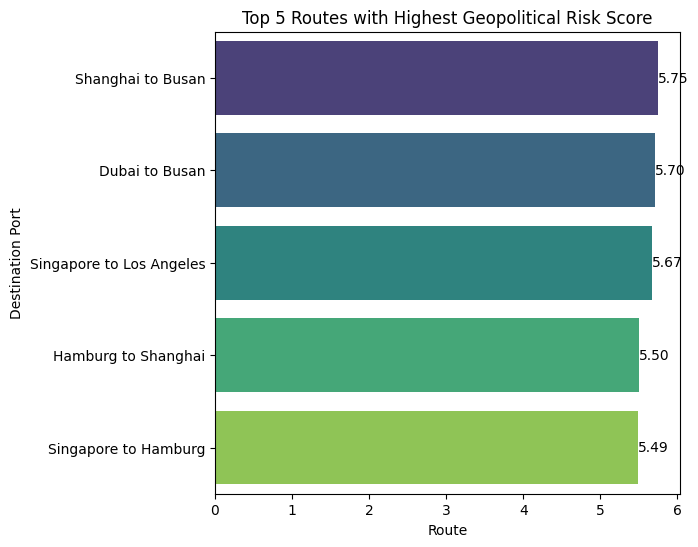

In [98]:
# Top 5 routes risk ranking
df['Route'] = df['Origin_Port'] + ' to ' + df['Destination_Port']

top_5 = df.groupby('Route')['Geopolitical_Risk_Score'].mean().nlargest(5).reset_index()


plt.figure(figsize=(6, 6))
ax = sns.barplot(y= 'Route', x= 'Geopolitical_Risk_Score', data= top_5 , palette='viridis')


for container in ax.containers:
  ax.bar_label(container, fmt = '%.2f')

plt.xlabel('Route')
plt.ylabel('Destination Port')
plt.xticks(rotation=0)
plt.title('Top 5 Routes with Highest Geopolitical Risk Score')


plt.show()

In [99]:
top_5 = df.groupby('Route')['Geopolitical_Risk_Score'].mean().nlargest(5).reset_index()
top_5

,Route,Geopolitical_Risk_Score
0,Shanghai to Busan,5.745977
1,Dubai to Busan,5.704615
2,Singapore to Los Angeles,5.673846
3,Hamburg to Shanghai,5.496104
4,Singapore to Hamburg,5.490805


In [100]:
top_5 = df.nlargest(5, 'Geopolitical_Risk_Score')
top_5

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Month,Month_Number,Route
145,SC-10145,2025-04-24,Singapore,Shanghai,Air,Automotive,1034.86,440.04,3.77,10.0,Storm,0.801,0.99,1,April,4,Singapore to Shanghai
289,SC-10289,2025-07-07,Rotterdam,Marseille,Sea,Textiles,9067.08,360.51,1.67,10.0,Hurricane,0.917,151.27,1,July,7,Rotterdam to Marseille
618,SC-10618,2025-07-24,Hamburg,Singapore,Rail,Automotive,12189.92,275.73,1.64,10.0,Storm,0.719,37.30,1,July,7,Hamburg to Singapore
779,SC-10779,2024-04-14,Shanghai,Antwerp,Road,Pharmaceuticals,9796.64,118.28,1.87,10.0,Rain,0.969,10.32,1,April,4,Shanghai to Antwerp
1057,SC-11057,2025-04-26,Dubai,Shanghai,Rail,Electronics,6328.00,245.67,4.29,10.0,Rain,0.776,8.44,0,April,4,Dubai to Shanghai


# PREDICTIVE ANALYTICS

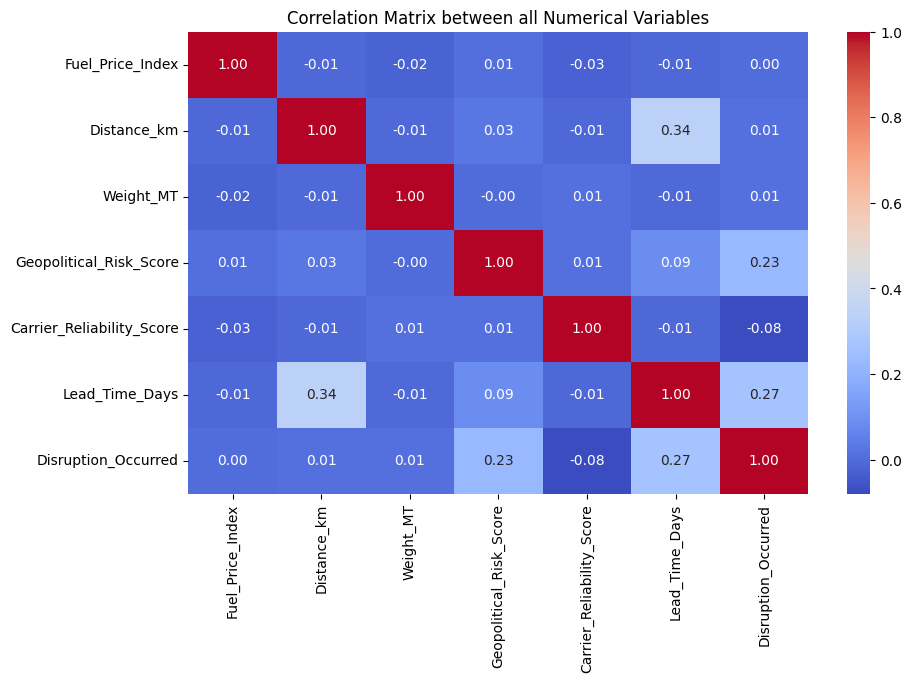

In [101]:
# CORRELATION MATRIX FOR ALL NUMERICAL COLUMNS USING HEATMAP
num_col = ['Fuel_Price_Index', 'Distance_km','Weight_MT', 'Geopolitical_Risk_Score','Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred'  ]

corr= df[num_col].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix between all Numerical Variables')

plt.savefig('correlation_matrix.png')
plt.show()

In [102]:
# prediction of lead times days against various factors like distance, weight, weather condition
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. Prepare Data
X = df[['Distance_km', 'Weight_MT', 'Weather_Condition']]
y = df['Lead_Time_Days']

# 2. Encode categorical text into numbers
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = model.predict(X_test)
print(f"Average Error: {mean_absolute_error(y_test, y_pred):.2f} days")

Average Error: 13.80 days


Total Shipments: 5000
Number of Anomalies Detected (Z > 3): 140

Top 5 Most Anomalous Shipments:
     Shipment_ID                     Route  Lead_Time_Days  \
1196    SC-11196  Los Angeles -> Marseille          220.25   
2431    SC-12431            Busan -> Dubai          207.59   
485     SC-10485        Dubai -> Singapore          212.15   
1054    SC-11054      Dubai -> Los Angeles          235.70   
4755    SC-14755          Antwerp -> Busan          175.29   

      Route_Avg_Lead_Time   Z_Score  
1196            13.566528  7.259542  
2431            16.190128  6.931974  
485             16.400385  6.767756  
1054            16.232025  6.762809  
4755            16.215050  6.382058  


/tmp/ipykernel_780/962353697.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Lead_Time_Days', y ='Route',  data=df[df['Route'].isin(top_anomaly_routes)], palette='Set2')


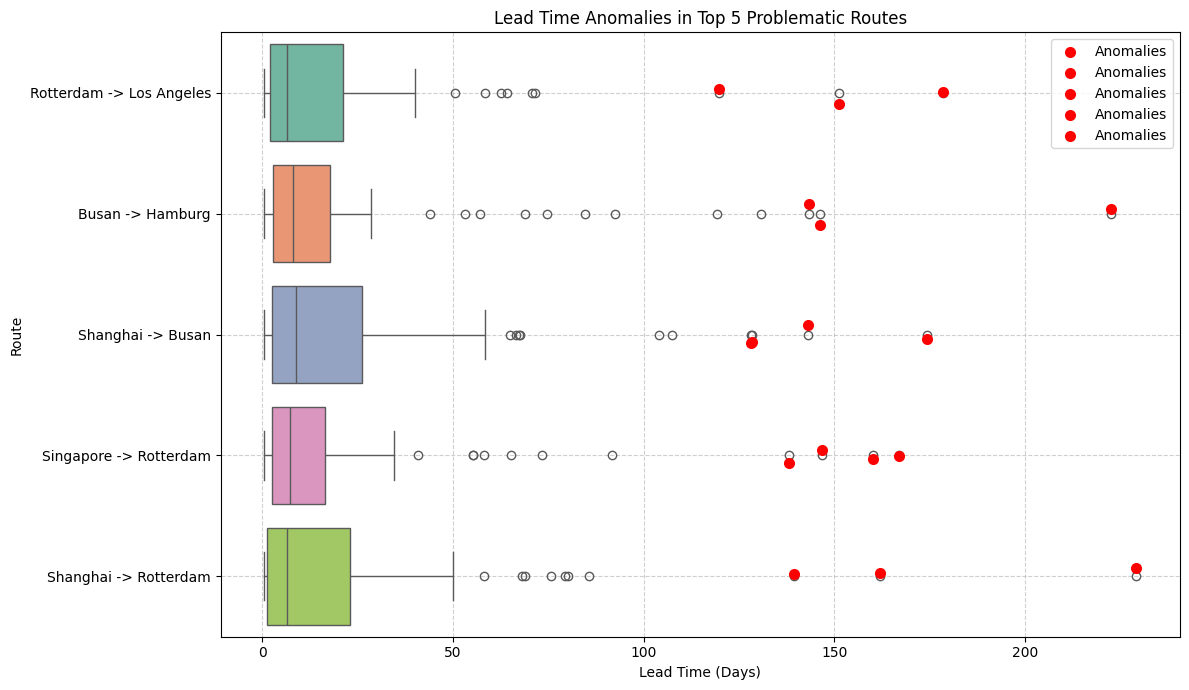

In [103]:
# Anomaly detection
# 1. Create a Route column
df['Route'] = df['Origin_Port'] + ' -> ' + df['Destination_Port']

# 2. Calculate Mean and Std Dev for Lead_Time_Days per Route
route_stats = df.groupby('Route')['Lead_Time_Days'].agg(['mean', 'std']).reset_index()
route_stats.columns = ['Route', 'Route_Avg_Lead_Time', 'Route_Std_Lead_Time']

# Merge stats back to main dataframe
df = df.merge(route_stats, on='Route')

# 3. Calculate Z-Score
# Z = (Value - Mean) / StdDev
# Small catch: if std is 0 (only 1 shipment on route), Z will be NaN. We fill with 0.
df['Z_Score'] = (df['Lead_Time_Days'] - df['Route_Avg_Lead_Time']) / df['Route_Std_Lead_Time']
df['Z_Score'] = df['Z_Score'].fillna(0)

# 4. Define Anomalies (Threshold: Z > 3 is standard for extreme outliers)
anomalies = df[df['Z_Score'] > 3].sort_values(by='Z_Score', ascending=False)

# 5. Summary for User
print(f"Total Shipments: {len(df)}")
print(f"Number of Anomalies Detected (Z > 3): {len(anomalies)}")
print("\nTop 5 Most Anomalous Shipments:")
print(anomalies[['Shipment_ID', 'Route', 'Lead_Time_Days', 'Route_Avg_Lead_Time', 'Z_Score']].head())

# 6. Save anomalies to CSV
anomalies.to_csv('lead_time_anomalies.csv', index=False)

# 7. Visualization: Boxplot of Lead Time for the top 5 routes with anomalies
top_anomaly_routes = anomalies['Route'].value_counts().head(5).index
plt.figure(figsize=(12,7))
sns.boxplot(x='Lead_Time_Days', y ='Route',  data=df[df['Route'].isin(top_anomaly_routes)], palette='Set2')
sns.stripplot(x='Lead_Time_Days', y='Route', data=anomalies[anomalies['Route'].isin(top_anomaly_routes)],
              color='red', size=8, label='Anomalies')
plt.title('Lead Time Anomalies in Top 5 Problematic Routes')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Route')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('anomaly_detection_plot.png')

In [104]:
df.groupby('Route')['Lead_Time_Days'].agg(['mean', 'std']).reset_index()

,Route,mean,std
0,Antwerp -> Busan,16.215050,24.925338
1,Antwerp -> Dubai,17.356500,32.223108
2,Antwerp -> Hamburg,19.015143,24.133930
3,Antwerp -> Los Angeles,17.502632,26.057023
4,Antwerp -> Marseille,18.927625,26.618682
...,...,...,...
59,Singapore -> Hamburg,20.399885,28.604424
60,Singapore -> Los Angeles,21.378462,38.413421
61,Singapore -> Marseille,13.865970,23.747932
62,Singapore -> Rotterdam,21.207123,36.927126


## Project Summary: Global Supply Chain Risk Analysis

In this collaborative project, my student and I analyzed the `global_supply_chain_risk_2026.csv` dataset, comprising **5000 records** of shipment data, with no missing values or duplicates identified. The primary objective was to understand various factors influencing supply chain disruptions and lead times.

### Key Findings:

1.  **Data Overview & Preparation**:
    *   The dataset contained information on 8 unique origin ports and 9 unique destination ports.
    *   Date data was successfully parsed, and 'Month' and 'Month_Number' columns were extracted for temporal analysis.

2.  **Descriptive Statistics**:
    *   Average shipment distance: **7704.06 km** (median: 7750.13 km).
    *   Average shipment weight: **246.25 MT** (median: 243.50 MT).

3.  **Transport Mode Analysis**:
    *   **Air transport** was the most frequent mode with **1320 shipments**, followed by Sea (1281), Road (1214), and Rail (1185).
    *   **990 shipments** out of 5000 experienced a **Hurricane** weather condition.
    *   When considering *only disrupted shipments*, the distribution across transport modes was relatively even:
        *   Air: **26.61%**
        *   Sea: **25.53%**
        *   Road: **24.19%**
        *   Rail: **23.67%**

4.  **Risk and Reliability Assessment**:
    *   **Carrier Reliability Scores** (mean) were consistently around **0.75-0.76** across all weather conditions, with 'Clear' weather showing the highest average (0.761) and 'Hurricane' the lowest (0.749).
    *   **Top 5 Routes with Highest Geopolitical Risk Score**:
        1.  Shanghai to Busan: **5.75**
        2.  Dubai to Busan: **5.70**
        3.  Singapore to Los Angeles: **5.67**
        4.  Hamburg to Shanghai: **5.50**
        5.  Singapore to Hamburg: **5.49**

5.  **Predictive Analytics & Anomaly Detection**:
    *   A linear regression model was developed to predict `Lead_Time_Days` based on `Distance_km`, `Weight_MT`, and `Weather_Condition`. The model achieved an **Average Error (MAE) of 13.80 days**.
    *   **140 anomalous shipments** were detected based on a Z-score greater than 3, indicating significantly longer lead times than expected for their respective routes. For example, a shipment on the Los Angeles -> Marseille route had a lead time of **220.25 days** with a Z-score of **7.26**, far exceeding its route's average lead time of 13.57 days.

# Collaborative Research Team
---
This project is a joint effort conducted by the following researchers:

-   Kevin Destiny | [connect via
LinkedIn](https://www.linkedin.com/in/destiny-kevin-0015861a4/)
-    Candance Chijoke-Mba | [connect via LinkedIn](https://www.linkedin.com/in/candace-chijioke-mba/)

